In [69]:
import numpy as np
import matplotlib.pyplot as  plt

# Preparing Input Data 

In [70]:
def generate_linear(n=100):   
    import numpy as np
    pts = np.random.uniform(0, 1, (n, 2)  )  # 隨機生成 n 個點，每個點有兩個特徵
    inputs = []
    labels = []     
    for pt in   pts :
        inputs.append([pt[0], pt[1]])
        distance = (pt[0] - pt[1]) / 1.414
        if pt[0] > pt[1]:
            labels.append(0)
        else:
            labels.append(1)
    return np.array(inputs), np.array(labels).reshape(n, 1)

inputs, labels = generate_linear()


#print("Inputs: {} , Labels: {}\n".format(inputs, labels))
print(inputs.shape)
print(labels.shape)
        

(100, 2)
(100, 1)


In [71]:
def generate_XOR_easy():
   # import numpy as np
    inputs = []
    labels = []
    for i in range(11):
        inputs.append([0.1 * i, 0.1 * i])
        labels.append(0)
        if 0.1 * i == 0.5:
            continue
        inputs.append([0.1 * i, 1 - 0.1 * i])
        labels.append(1)
    return np.array(inputs), np.array(labels).reshape(21, 1)

inputs, labels = generate_XOR_easy()
print(inputs.shape)
print(labels.shape)

(21, 2)
(21, 1)


# Activation function

In [72]:
def Sigmoid(x):
    return 1/ (1.0+np.exp(-x))
def Derivative_Sigmoid(x): 
    return x * (1 - x)

In [73]:
def ReLu(x):
    return np.where(x>0,x,0)
def Derivative_ReLu(x):
    return np.where(x>0,1,0)

In [74]:
def tanh(x):
    return np.tanh(x)
def  Derivative_tanh(x):
    return 1 - np.multiply(x, x)

# Some utility


In [75]:
def show_result(x, y, pred_y):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 7))
    #plotting the ground truth
    plt.subplot(1,2,1,aspect='equal')
    plt.title('Ground truth', fontsize=18)
    for i in range(x.shape[0]):
        if y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro') #red 0
        else:
            plt.plot(x[i][0], x[i][1], 'bo') #blue 1

    #plotting predicting
    plt.subplot(1,2,2,aspect='equal')
    plt.text(0, 0, f'Accuracy: {sum(pred_y == y)/y.size}', fontsize = 16, 
         bbox = dict(facecolor = 'white', alpha = 0.5))
    plt.title('Predict result', fontsize=18)
    for i in range(x.shape[0]):
        if pred_y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro')
        else:
            plt.plot(x[i][0], x[i][1], 'bo')

In [76]:
def show_result_compare(x, y, predlr1_y,predlr2_y,label1,label2):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 7))
    #plotting the ground truth
    plt.subplot(1,3,1,aspect='equal')
    plt.title('Ground truth', fontsize=18)
    for i in range(x.shape[0]):
        if y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro') #red 0
        else:
            plt.plot(x[i][0], x[i][1], 'bo') #blue 1

    #plotting predicting
    plt.subplot(1,3,2,aspect='equal')
    plt.text(0, 0, f'Accuracy: {sum(predlr1_y == y)/y.size}', fontsize = 16, 
         bbox = dict(facecolor = 'white', alpha = 0.5))
    plt.title(label1, fontsize=18)
    for i in range(x.shape[0]):
        if predlr1_y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro')
        else:
            plt.plot(x[i][0], x[i][1], 'bo')
            
    #plotting predicting
    plt.subplot(1,3,3,aspect='equal')
    plt.text(0, 0, f'Accuracy: {sum(predlr2_y == y)/y.size}', fontsize = 16, 
         bbox = dict(facecolor = 'white', alpha = 0.5))
    plt.title(label2, fontsize=18)
    for i in range(x.shape[0]):
        if predlr2_y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro')
        else:
            plt.plot(x[i][0], x[i][1], 'bo')

In [77]:
def show(x,y,model,epochs):
    print("--------- Training -----------")
    loss_list = []
    epoch_list = []

    plt.title("Learning Curve")
    for epoch in range(1, epochs + 1):
        y_test = model.forward(x)
        loss = model.back_propagation(x, y)
        
        if( (epoch) % 10000 == 0):
            print(f"epoch: {epoch} loss: {loss}")
        #每100更新loss
        if( epoch % 100 == 0):
            loss_list.append(loss)
            epoch_list.append(epoch)
            
    plt.plot(epoch_list, loss_list)
    plt.ylabel('loss', fontsize = 14)
    plt.xlabel('epochs', fontsize = 14)

    # testing
    print("------------- Testing ------------")
    y_pred_probability = model.forward(x)
    print(y_pred_probability)
    # >0.5 -> label 1 <0.5 ->label 0
    y_pred = np.where(y_pred_probability > 0.5, 1, 0)

    print("------------Iteration---------------")

    for i in range(y_pred_probability.size) :
        print(f"Iter:{i+1} |      Ground truth : {y[i]} |   prediction : {y_pred_probability[i]}")
        

    print("---------accuracy----------------------")
    print("accuracy: ", sum(1 for i, j in zip(y, y_pred) if i == j) / len(y) * 100 ,"%")
    
    print("----------Graph-----------------------------")
    show_result(x,y,y_pred)


In [78]:
def compare(x,y,model1,model2,label1,label2,epochs):
    print(f"--------- {label1} Training -----------")
    loss_list = []
    epoch_list = []

    plt.title("Learning Curve")
    for epoch in range(1, epochs + 1):
        y_test = model1.forward(x)
        loss = model1.back_propagation(x, y)
        
        if(epoch % 1000 == 0):
            print(f"epoch: {epoch} loss: {loss}")
        #每100更新loss
        if(epoch % 100 == 0):
            loss_list.append(loss)
            epoch_list.append(epoch)
            
    plt.plot(epoch_list, loss_list, label=label1)
    plt.ylabel('loss', fontsize = 14)
    plt.xlabel('epochs', fontsize = 14)

    # testing
    print(f"-------------{label1} Testing ------------")
    y_pred_probability = model1.forward(x)
    print(y_pred_probability)
    # >0.5 -> label 1 <0.5 ->label 0
    y_pred1 = np.where(y_pred_probability > 0.5, 1, 0)

    print(f"------------{label1} Iteration---------------")

    for i in range(y_pred_probability.size) :
        print(f"Iter:{i+1} |      Ground truth : {y[i]} |   prediction : {y_pred_probability[i]}")
        

    print("---------accuracy----------------------")
    print("accuracy: ", sum(1 for i, j in zip(y, y_pred1) if i == j) / len(y) * 100 ,"%")




    #############################################################################


    # training
    print(f"--------- {label2} Training -----------")
    loss_list = []
    epoch_list = []

    plt.title("Learning Curve")
    for epoch in range(1, epochs + 1):
        y_test = model2.forward(x)
        loss = model2.back_propagation(x, y)
        
        if(epoch % 1000 == 0):
            print(f"epoch: {epoch} loss: {loss}")
        #每100更新loss
        if(epoch % 100 == 0):
            loss_list.append(loss)
            epoch_list.append(epoch)
            


    # testing
    print(f"------------- {label2}Testing ------------")
    y_pred_probability = model2.forward(x)
    print(y_pred_probability)
    # >0.5 -> label 1 <0.5 ->label 0
    y_pred2 = np.where(y_pred_probability > 0.5, 1, 0)

    print(f"------------{label2} Iteration---------------")

    for i in range(y_pred_probability.size) :
        print(f"Iter:{i+1} |      Ground truth : {y[i]} |   prediction : {y_pred_probability[i]}")
        

    print("---------accuracy----------------------")
    print("accuracy: ", sum(1 for i, j in zip(y, y_pred2) if i == j) / len(y) * 100 ,"%")

    print("---------------LR curve---------------")
    plt.plot(epoch_list, loss_list , label=label2)
    plt.legend()
    plt.show()
    
    show_result_compare(x,y,y_pred1,y_pred2,label1,label2)

# Model

In [79]:
class Model:
    def __init__ (self,input_size=2,hidden1_size=10,hidden2_size=10,output_size=1,
                  learning_rate = 0.1 ,activate = "Sigmoid", optimizer="SGD",decay=0.9):
        # init
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.output_size = output_size
        self.activate = activate
        self.learning_rate = learning_rate
        self.optimizer = optimizer
        
        #weight bias setting
        self.W1 = np.random.randn(input_size,hidden1_size)
        self.W2 = np.random.randn(hidden1_size,hidden2_size)
        self.W3 = np.random.randn(hidden2_size,output_size)
        
        self.y=()
        
        self.b1 = np.random.randn(1,hidden1_size)/100
        self.b2 = np.random.randn(1,hidden2_size)/100
        self.b3 = np.random.randn(1,output_size)/100
        
        # Define hyperparameters for Momentum optimizer
        self.v_W1 = 0  # Velocity for W1
        self.v_W2 = 0  # Velocity for W2
        self.v_W3 = 0  # Velocity for W3
        self.v_b1 = 0  # Velocity for b1
        self.v_b2 = 0  # Velocity for b2
        self.v_b3 = 0  # Velocity for b3
        self.decay =decay
        
    def forward(self , x)    :
        self.x = x
        #first layer
        
        self.hidden1 = np.dot(x,self.W1) + self.b1
        
        if(self.activate == "Sigmoid") :
            self.hidden1 = Sigmoid(self.hidden1)
        elif(self.activate == "ReLu") :
            self.hidden1 = ReLu(self.hidden1)
        elif(self.activate == "tanh") :
            self.hidden1 = tanh(self.hidden1)
        elif self.activate == "None":
            pass
       
        
        #second layer
        self.hidden2 = np.dot(self.hidden1,self.W2) + self.b2
        
        if(self.activate == "Sigmoid") :
            self.hidden2 = Sigmoid(self.hidden2)
        elif(self.activate == "ReLu") :
            self.hidden2 = ReLu(self.hidden2)
        elif(self.activate == "tanh") :
            self.hidden2 = tanh(self.hidden2)
        elif self.activate == "None":
            pass
        
        
        #output layer
        
        self.y = np.dot(self.hidden2,self.W3) + self.b3
        
        if(self.activate == "Sigmoid") :
            self.y = Sigmoid(self.y)
        elif(self.activate == "ReLu") :
            self.y = ReLu(self.y)
        elif(self.activate == "tanh") :
           self.y = tanh(self.y)
        elif self.activate == "None":
            pass
       
        return self.y
    
    def clip_gradients(self, grad, threshold=1.0):
        grad = np.clip(grad, -threshold, threshold)
        return grad

    def back_propagation(self,x,y_gt):
        #update w3 b3
        y_error =(self.y - y_gt) 
        # error 乘 activation function的導數
        # 算gradient
        if(self.activate == "Sigmoid") :
            grad = y_error * Derivative_Sigmoid(self.y)
        elif(self.activate == "ReLu") :
            grad = y_error * Derivative_ReLu(self.y)
        elif(self.activate == "tanh") :
            grad = y_error * Derivative_tanh(self.y)
        elif self.activate == "None":
            grad=y_error
            
        grad = self.clip_gradients(grad)
            
        if(self.optimizer == "SGD"):
            #update
            self.W3 -= self.learning_rate * np.dot(self.hidden2.T,grad)
            self.b3 -= self.learning_rate * np.sum(grad,axis=0)
        elif(self.optimizer == "Momentum"):
            self.v_W3 = self.decay *self.v_W3 + self.learning_rate * np.dot(self.hidden2.T,grad)
            self.v_b3 =self.decay *self.v_b3 + self.learning_rate * np.sum(grad,axis=0)
            self.W3 -= self.v_W3
            self.b3 -= self.b3
            
            #update w2 b2
        hidden2_error = np.dot(grad,self.W3.T)
        if(self.activate == "Sigmoid") :
            grad = hidden2_error * Derivative_Sigmoid(self.hidden2)
        elif(self.activate == "ReLu") :
            grad = hidden2_error * Derivative_ReLu(self.hidden2)
        elif(self.activate == "tanh") :
            grad = hidden2_error * Derivative_tanh(self.hidden2)
        elif self.activate == "None":
            grad=hidden2_error
            
        grad = self.clip_gradients(grad)
            
        #update
        if(self.optimizer == "SGD"):
            self.W2 -= self.learning_rate * np.dot(self.hidden1.T,grad)
            self.b2 -= self.learning_rate * np.sum(grad,axis=0)
        elif(self.optimizer == "Momentum"):
            self.v_W2 = self.decay *self.v_W2 + self.learning_rate * np.dot(self.hidden1.T,grad)
            self.v_b2 =self.decay *self.v_b2 + self.learning_rate * np.sum(grad,axis=0)
            self.W2 -= self.v_W2
            self.b2 -= self.b2
        #update w1 b1
        hidden1_error = np.dot(grad,self.W2.T)
        if(self.activate == "Sigmoid") :
            grad = hidden1_error * Derivative_Sigmoid(self.hidden1)
        elif(self.activate == "ReLu") :
            grad = hidden1_error * Derivative_ReLu(self.hidden1)
        elif(self.activate == "tanh") :
            grad = hidden1_error* Derivative_tanh(self.hidden1)
        elif self.activate == "None":
            grad = hidden1_error
            
        grad = self.clip_gradients(grad)
            
        #update
        if(self.optimizer == "SGD"):
            self.W1 -= self.learning_rate * np.dot(x.T,grad)
            self.b1 -= self.learning_rate * np.sum(grad,axis=0)
        elif(self.optimizer == "Momentum"):
            self.v_W1 = self.decay *self.v_W1 + self.learning_rate * np.dot(x.T,grad)
            self.v_b1 =self.decay *self.v_b1 + self.learning_rate * np.sum(grad,axis=0)
            self.W1 -= self.v_W1
            self.b1 -= self.b1
        
        return  np.sum ((self.y-y_gt) ** 2)/self.y.shape[0]  
    
        
            

# Train 

## Linear Data

--------- Training -----------
epoch: 10000 loss: 0.00013545115162314232
epoch: 20000 loss: 4.732421105962058e-05
epoch: 30000 loss: 2.6309787810163037e-05
epoch: 40000 loss: 1.758339340494068e-05
epoch: 50000 loss: 1.2957044137994639e-05
epoch: 60000 loss: 1.0140621938118715e-05
epoch: 70000 loss: 8.266294196663323e-06
epoch: 80000 loss: 6.9389128081927394e-06
epoch: 90000 loss: 5.954773437112586e-06
epoch: 100000 loss: 5.198984012577834e-06
------------- Testing ------------
[[9.99999993e-01]
 [1.46073750e-08]
 [4.03628737e-03]
 [1.28468289e-08]
 [9.99999996e-01]
 [1.30576488e-08]
 [3.25124587e-06]
 [1.30004758e-08]
 [1.39405127e-08]
 [1.52573901e-08]
 [9.99997413e-01]
 [2.32856816e-08]
 [9.99999996e-01]
 [9.99999995e-01]
 [1.34325294e-08]
 [4.03183864e-08]
 [9.99999994e-01]
 [9.99999958e-01]
 [9.99999996e-01]
 [9.99999996e-01]
 [2.19466621e-08]
 [9.99999995e-01]
 [9.99999923e-01]
 [9.99999996e-01]
 [1.38216888e-08]
 [9.99999992e-01]
 [4.53611534e-08]
 [9.99999996e-01]
 [1.35059664e-

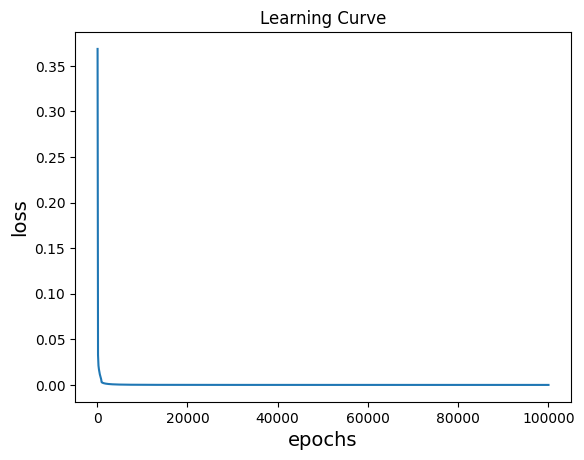

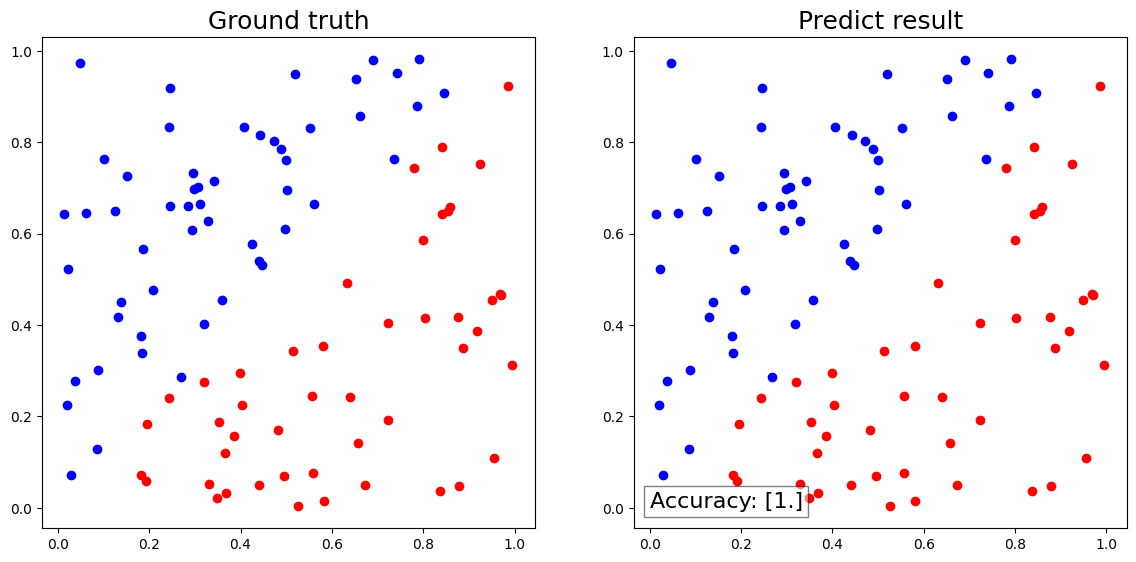

In [96]:
x,y =generate_linear()
epochs = 100000
model = Model()
# training
show(x,y,model,epochs)


## XOR data

--------- Training -----------
epoch: 10000 loss: 0.00021773497604883632
epoch: 20000 loss: 9.51138468520335e-05
epoch: 30000 loss: 6.006981581740473e-05
epoch: 40000 loss: 4.367365152295725e-05
epoch: 50000 loss: 3.42172495243767e-05
epoch: 60000 loss: 2.8081253504473856e-05
epoch: 70000 loss: 2.3785425414458892e-05
epoch: 80000 loss: 2.0613624946162193e-05
epoch: 90000 loss: 1.817777759136795e-05
epoch: 100000 loss: 1.6249583173655037e-05
------------- Testing ------------
[[0.0027941 ]
 [0.99913156]
 [0.00310773]
 [0.9991233 ]
 [0.00344662]
 [0.99909529]
 [0.00376602]
 [0.99892579]
 [0.00402301]
 [0.99146354]
 [0.00419375]
 [0.00427896]
 [0.99164726]
 [0.00429691]
 [0.99713842]
 [0.0042734 ]
 [0.99738586]
 [0.00423487]
 [0.99750701]
 [0.00420465]
 [0.99756724]]
------------Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.0027941]
Iter:2 |      Ground truth : [1] |   prediction : [0.99913156]
Iter:3 |      Ground truth : [0] |   prediction : [0.00310773]


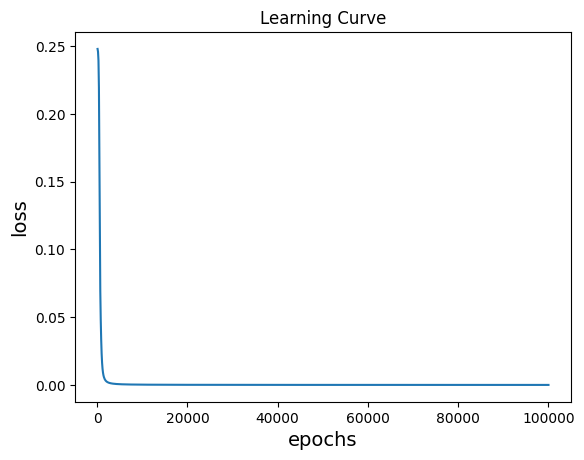

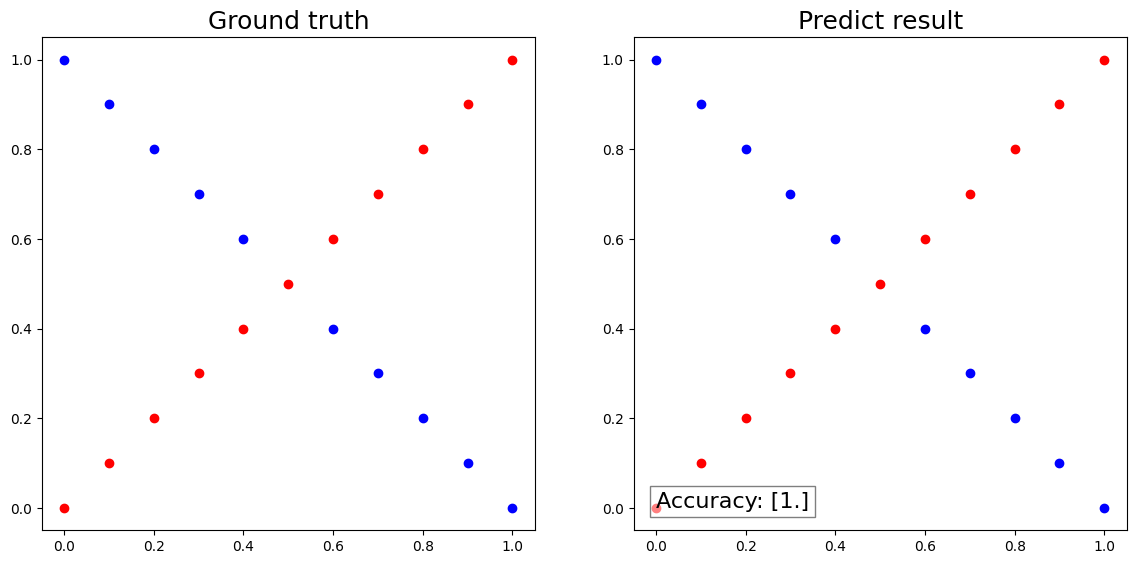

In [97]:
X_xor,Y_xor =generate_XOR_easy()

epochs = 100000
model = Model()
# training
show(X_xor,Y_xor,model,epochs)

# Discussion

## Differnet LR

### Linear Data

--------- lr=0.001 Training -----------
epoch: 1000 loss: 0.20166979130090834
epoch: 2000 loss: 0.11857799652026077
epoch: 3000 loss: 0.07500859768822982
epoch: 4000 loss: 0.055822148443924614
epoch: 5000 loss: 0.04532300349302568
-------------lr=0.001 Testing ------------
[[0.70118979]
 [0.10670373]
 [0.01580665]
 [0.87733347]
 [0.03304792]
 [0.23517801]
 [0.10301244]
 [0.98124037]
 [0.05379511]
 [0.97781229]
 [0.8943058 ]
 [0.92691239]
 [0.80052894]
 [0.98510739]
 [0.61780279]
 [0.98033639]
 [0.97844389]
 [0.25170847]
 [0.64806021]
 [0.65692227]
 [0.75241157]
 [0.09463996]
 [0.03329508]
 [0.07750216]
 [0.08833773]
 [0.98242484]
 [0.06827932]
 [0.07165616]
 [0.1007931 ]
 [0.98267877]
 [0.6958561 ]
 [0.56591957]
 [0.24393306]
 [0.69859606]
 [0.04284817]
 [0.28023082]
 [0.95744071]
 [0.95737939]
 [0.68361449]
 [0.90424704]
 [0.96782305]
 [0.36985263]
 [0.01940312]
 [0.14751501]
 [0.98169106]
 [0.96499554]
 [0.02016501]
 [0.31810851]
 [0.19655573]
 [0.20893985]
 [0.22349549]
 [0.77448784

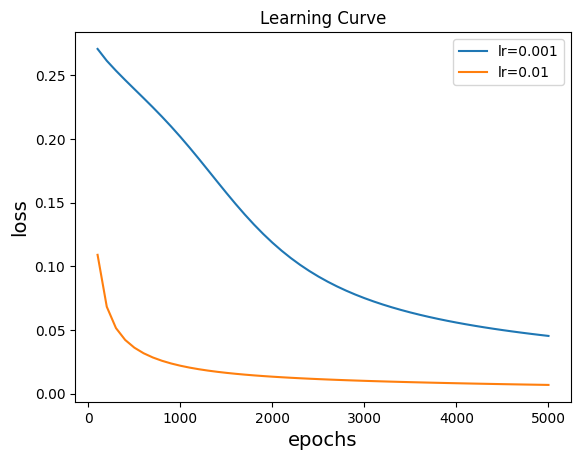

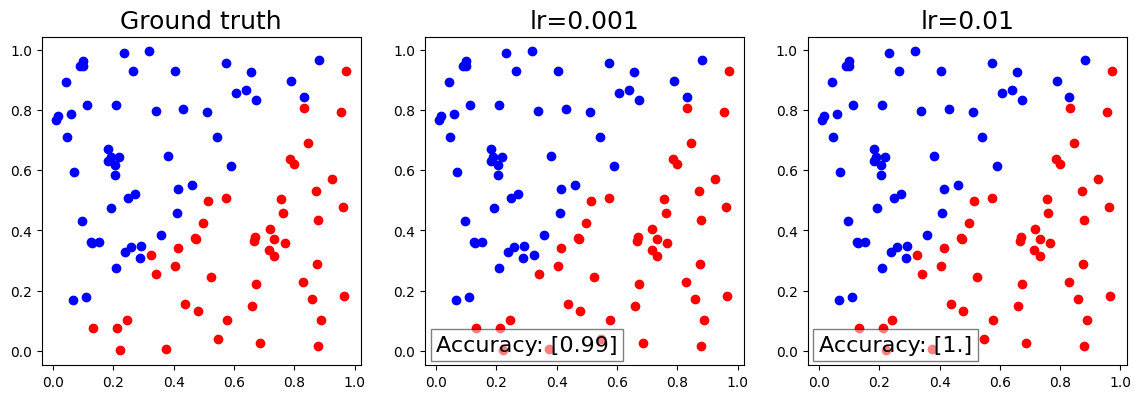

In [95]:
x,y =generate_linear()
epochs = 5000
model1  = Model(learning_rate=0.001)
model2 = Model(learning_rate=0.01)
# training

compare(x,y,model1,model2,"lr=0.001","lr=0.01",epochs)



### XOR Data

--------- lr=0.001 Training -----------
epoch: 1000 loss: 0.24872911079345172
epoch: 2000 loss: 0.24760954371636035
epoch: 3000 loss: 0.2465193901664401
epoch: 4000 loss: 0.2454255776555584
epoch: 5000 loss: 0.24430177906289577
epoch: 6000 loss: 0.24312621500752687
epoch: 7000 loss: 0.24188070777571377
epoch: 8000 loss: 0.24055051236167144
epoch: 9000 loss: 0.2391245083188016
epoch: 10000 loss: 0.2375953419859192
-------------lr=0.001 Testing ------------
[[0.3503161 ]
 [0.57480831]
 [0.38188184]
 [0.55447503]
 [0.41372322]
 [0.53521182]
 [0.44277409]
 [0.51718526]
 [0.46683453]
 [0.50049354]
 [0.48518415]
 [0.4982729 ]
 [0.47127044]
 [0.50709233]
 [0.45874429]
 [0.51271146]
 [0.44758282]
 [0.51605929]
 [0.43774783]
 [0.51786538]
 [0.42917922]]
------------lr=0.001 Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.3503161]
Iter:2 |      Ground truth : [1] |   prediction : [0.57480831]
Iter:3 |      Ground truth : [0] |   prediction : [0.38188184]
Iter:4 |   

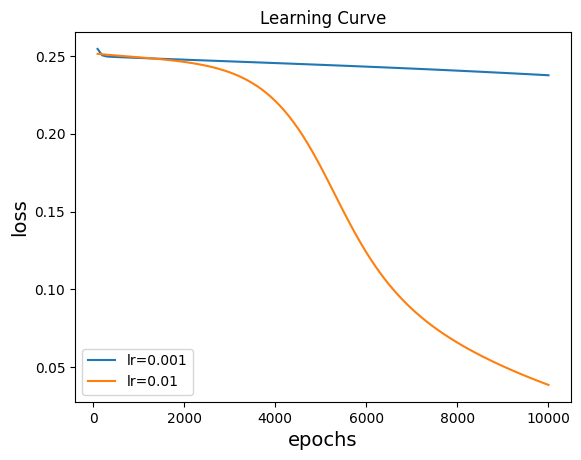

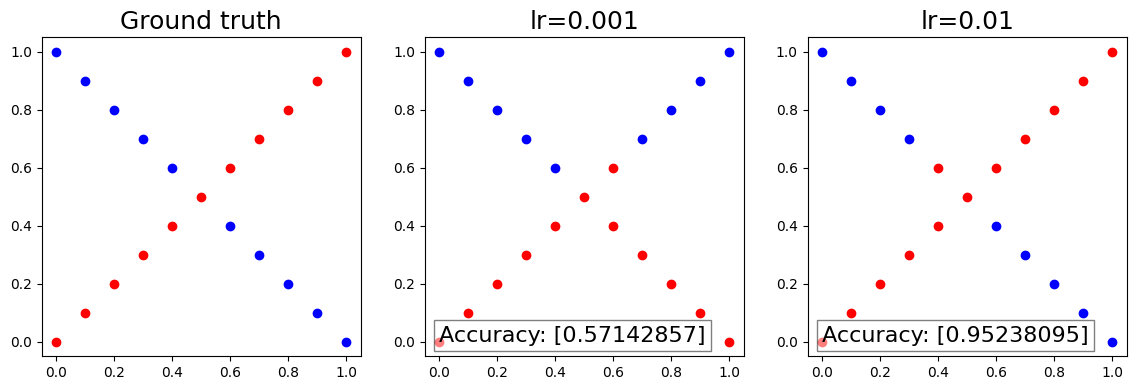

In [83]:
x_xor,y_xor =generate_XOR_easy()
epochs = 10000
model1  = Model(learning_rate=0.001)
model2 = Model(learning_rate=0.01)
# training
compare(x_xor,y_xor,model1,model2,"lr=0.001","lr=0.01",epochs)


## Different hidden layer (2 vs 4)

In [84]:
class Model_4layer:
    def __init__(self, input_size=2, hidden1_size=10, hidden2_size=10, hidden3_size=10, hidden4_size=10, 
                 output_size=1, learning_rate=0.1, activate="Sigmoid"):
        # init
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.hidden3_size = hidden3_size
        self.hidden4_size = hidden4_size
        self.output_size = output_size
        self.activate = activate
        self.learning_rate = learning_rate
        
        # weight and bias initialization
        self.W1 = np.random.randn(input_size, hidden1_size)
        self.W2 = np.random.randn(hidden1_size, hidden2_size)
        self.W3 = np.random.randn(hidden2_size, hidden3_size)
        self.W4 = np.random.randn(hidden3_size, hidden4_size)
        self.W5 = np.random.randn(hidden4_size, output_size)
        
        self.b1 = np.random.randn(1, hidden1_size) / 100
        self.b2 = np.random.randn(1, hidden2_size) / 100
        self.b3 = np.random.randn(1, hidden3_size) / 100
        self.b4 = np.random.randn(1, hidden4_size) / 100
        self.b5 = np.random.randn(1, output_size) / 100
    
    def forward(self, x):
        self.x = x
        
        # First hidden layer
        self.hidden1 = np.dot(x, self.W1) + self.b1
        if self.activate == "Sigmoid":
            self.hidden1 = Sigmoid(self.hidden1)
        elif self.activate == "ReLu":
            self.hidden1 = ReLu(self.hidden1)
        elif self.activate == "tanh":
            self.hidden1 = tanh(self.hidden1)
        
        # Second hidden layer
        self.hidden2 = np.dot(self.hidden1, self.W2) + self.b2
        if self.activate == "Sigmoid":
            self.hidden2 = Sigmoid(self.hidden2)
        elif self.activate == "ReLu":
            self.hidden2 = ReLu(self.hidden2)
        elif self.activate == "tanh":
            self.hidden2 = tanh(self.hidden2)
        
        # Third hidden layer
        self.hidden3 = np.dot(self.hidden2, self.W3) + self.b3
        if self.activate == "Sigmoid":
            self.hidden3 = Sigmoid(self.hidden3)
        elif self.activate == "ReLu":
            self.hidden3 = ReLu(self.hidden3)
        elif self.activate == "tanh":
            self.hidden3 = tanh(self.hidden3)
        
        # Fourth hidden layer
        self.hidden4 = np.dot(self.hidden3, self.W4) + self.b4
        if self.activate == "Sigmoid":
            self.hidden4 = Sigmoid(self.hidden4)
        elif self.activate == "ReLu":
            self.hidden4 = ReLu(self.hidden4)
        elif self.activate == "tanh":
            self.hidden4 = tanh(self.hidden4)
        
        # Output layer
        self.y = np.dot(self.hidden4, self.W5) + self.b5
        if self.activate == "Sigmoid":
            self.y = Sigmoid(self.y)
        elif self.activate == "ReLu":
            self.y = ReLu(self.y)
        elif self.activate == "tanh":
            self.y = tanh(self.y)
        
        return self.y
    
    def clip_gradients(self, grad, threshold=1.0):
        grad = np.clip(grad, -threshold, threshold)
        return grad
    
    def back_propagation(self, x, y_gt):
        # Update W5 and b5
        y_error = (self.y - y_gt)
        if self.activate == "Sigmoid":
            grad = y_error * Derivative_Sigmoid(self.y)
        elif self.activate == "ReLu":
            grad = y_error * Derivative_ReLu(self.y)
        elif self.activate == "tanh":
            grad = y_error * Derivative_tanh(self.y)
        grad = self.clip_gradients(grad)
        
        self.W5 -= self.learning_rate * np.dot(self.hidden4.T, grad)
        self.b5 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W4 and b4
        hidden4_error = np.dot(grad, self.W5.T)
        if self.activate == "Sigmoid":
            grad = hidden4_error * Derivative_Sigmoid(self.hidden4)
        elif self.activate == "ReLu":
            grad = hidden4_error * Derivative_ReLu(self.hidden4)
        elif self.activate == "tanh":
            grad = hidden4_error * Derivative_tanh(self.hidden4)
        grad = self.clip_gradients(grad)
        
        self.W4 -= self.learning_rate * np.dot(self.hidden3.T, grad)
        self.b4 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W3 and b3
        hidden3_error = np.dot(grad, self.W4.T)
        if self.activate == "Sigmoid":
            grad = hidden3_error * Derivative_Sigmoid(self.hidden3)
        elif self.activate == "ReLu":
            grad = hidden3_error * Derivative_ReLu(self.hidden3)
        elif self.activate == "tanh":
            grad = hidden3_error * Derivative_tanh(self.hidden3)
        grad = self.clip_gradients(grad)
        
        self.W3 -= self.learning_rate * np.dot(self.hidden2.T, grad)
        self.b3 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W2 and b2
        hidden2_error = np.dot(grad, self.W3.T)
        if self.activate == "Sigmoid":
            grad = hidden2_error * Derivative_Sigmoid(self.hidden2)
        elif self.activate == "ReLu":
            grad = hidden2_error * Derivative_ReLu(self.hidden2)
        elif self.activate == "tanh":
            grad = hidden2_error * Derivative_tanh(self.hidden2)
        grad = self.clip_gradients(grad)
        
        self.W2 -= self.learning_rate * np.dot(self.hidden1.T, grad)
        self.b2 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W1 and b1
        hidden1_error = np.dot(grad, self.W2.T)
        if self.activate == "Sigmoid":
            grad = hidden1_error * Derivative_Sigmoid(self.hidden1)
        elif self.activate == "ReLu":
            grad = hidden1_error * Derivative_ReLu(self.hidden1)
        elif self.activate == "tanh":
            grad = hidden1_error * Derivative_tanh(self.hidden1)
        grad = self.clip_gradients(grad)
        
        self.W1 -= self.learning_rate * np.dot(x.T, grad)
        self.b1 -= self.learning_rate * np.sum(grad, axis=0)
    
        return np.sum((self.y - y_gt) ** 2) / self.y.shape[0]

### Linear

--------- 2-layer Training -----------
epoch: 1000 loss: 0.4370071072106776
epoch: 2000 loss: 0.4366349904101788
epoch: 3000 loss: 0.4361586718287348
epoch: 4000 loss: 0.4355277780818762
epoch: 5000 loss: 0.43465360568239136
epoch: 6000 loss: 0.43336458100125197
epoch: 7000 loss: 0.431281915997934
epoch: 8000 loss: 0.42738265830342825
epoch: 9000 loss: 0.41774835502095947
epoch: 10000 loss: 0.3703706196124629
epoch: 11000 loss: 0.21299759665409826
epoch: 12000 loss: 0.20440854975538994
epoch: 13000 loss: 0.1962848054939056
epoch: 14000 loss: 0.18795763125476111
epoch: 15000 loss: 0.17955077583808193
epoch: 16000 loss: 0.17116976889906987
epoch: 17000 loss: 0.16290564811725336
epoch: 18000 loss: 0.1548418956439615
epoch: 19000 loss: 0.14705581154393588
epoch: 20000 loss: 0.1396146433119505
-------------2-layer Testing ------------
[[0.45639244]
 [0.66646914]
 [0.83096677]
 [0.61630626]
 [0.42809845]
 [0.30769308]
 [0.60645136]
 [0.27123163]
 [0.61448797]
 [0.64167945]
 [0.62267185]
 [0.

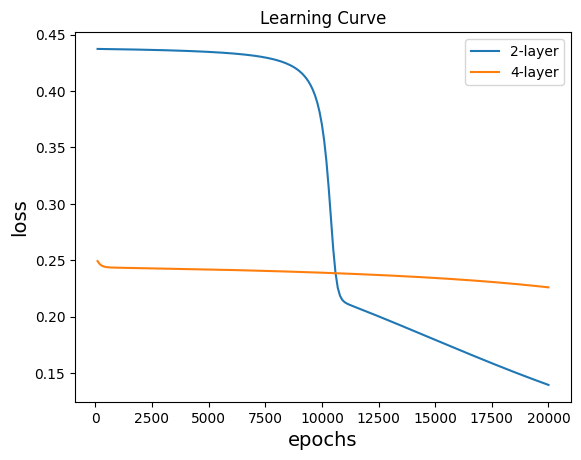

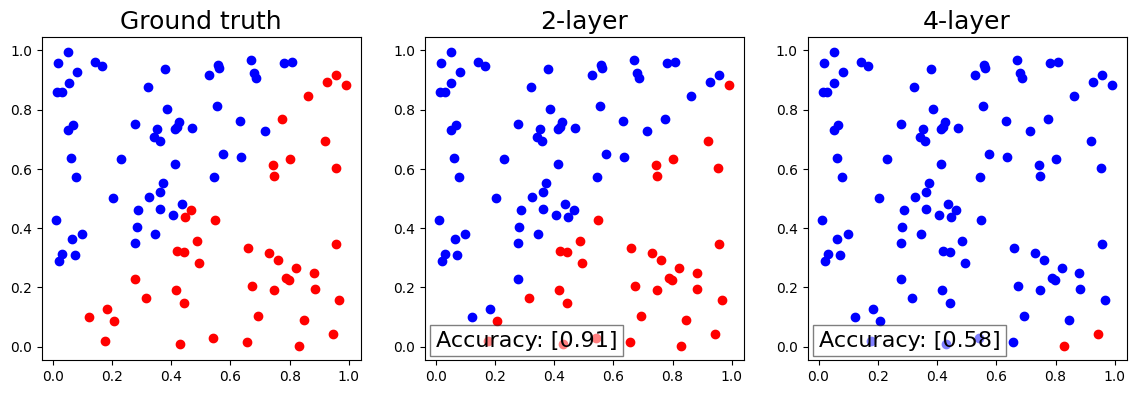

In [85]:
x,y =generate_linear()
epochs = 20000
model1  = Model(learning_rate=1e-4)
model2 = Model_4layer(learning_rate=1e-4)

compare(x,y,model1,model2,"2-layer","4-layer",epochs)

### XOR Data

--------- 2-layer Training -----------
epoch: 1000 loss: 0.22781771706908988
epoch: 2000 loss: 0.17773409198590517
epoch: 3000 loss: 0.11180382323362983
epoch: 4000 loss: 0.07334426202702422
epoch: 5000 loss: 0.05110758018127272
epoch: 6000 loss: 0.03549043718885866
epoch: 7000 loss: 0.024383330119072892
epoch: 8000 loss: 0.017029772081514554
-------------2-layer Testing ------------
[[0.09531257]
 [0.96990702]
 [0.10209881]
 [0.96770918]
 [0.10854708]
 [0.963237  ]
 [0.11381813]
 [0.94741841]
 [0.11728616]
 [0.72937794]
 [0.11869806]
 [0.11816735]
 [0.70811447]
 [0.1160494 ]
 [0.95488643]
 [0.1127914 ]
 [0.97657204]
 [0.10882067]
 [0.9819186 ]
 [0.10448749]
 [0.98387398]]
------------2-layer Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.09531257]
Iter:2 |      Ground truth : [1] |   prediction : [0.96990702]
Iter:3 |      Ground truth : [0] |   prediction : [0.10209881]
Iter:4 |      Ground truth : [1] |   prediction : [0.96770918]
Iter:5 |      Ground 

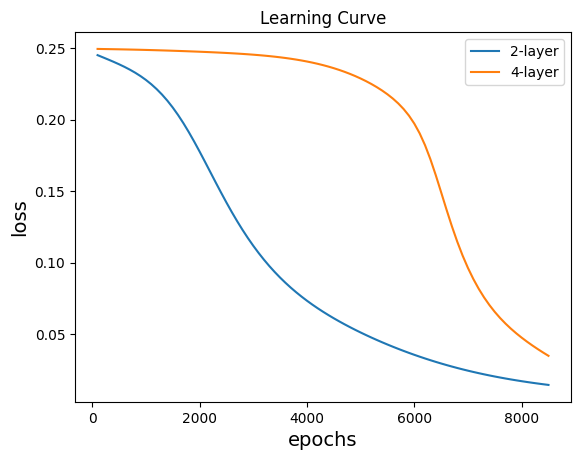

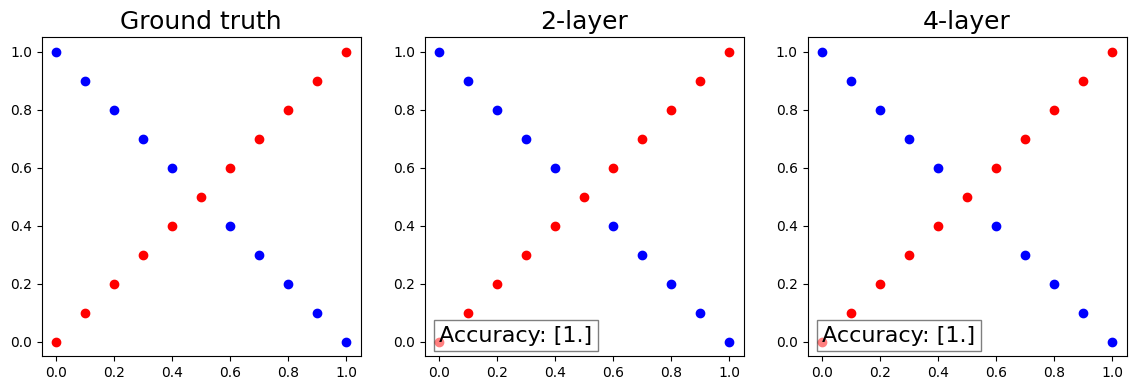

In [86]:
x_xor,y_xor =generate_XOR_easy()
epochs = 8500
model1  = Model(learning_rate=1e-2)
model2 = Model_4layer(learning_rate=1e-2)

compare(x_xor,y_xor,model1,model2,"2-layer","4-layer",epochs)

## No activate function

### Linear Data

--------- activate Training -----------
epoch: 1000 loss: 0.2747282942481747
epoch: 2000 loss: 0.2705689472731779
epoch: 3000 loss: 0.2672423832380033
epoch: 4000 loss: 0.26445057912609854
epoch: 5000 loss: 0.26205931454254466
epoch: 6000 loss: 0.25996554335114036
epoch: 7000 loss: 0.2580889566588973
epoch: 8000 loss: 0.25636535551042733
epoch: 9000 loss: 0.25474156846328894
epoch: 10000 loss: 0.25317156789481077
epoch: 11000 loss: 0.25161344357284293
epoch: 12000 loss: 0.25002695705207834
epoch: 13000 loss: 0.24837147565584267
epoch: 14000 loss: 0.24660415885799222
epoch: 15000 loss: 0.24467834753275777
epoch: 16000 loss: 0.24254219939156052
epoch: 17000 loss: 0.24013773434836788
epoch: 18000 loss: 0.23740060529774606
epoch: 19000 loss: 0.23426106958183696
epoch: 20000 loss: 0.23064672641154801
epoch: 21000 loss: 0.2264874568790013
epoch: 22000 loss: 0.22172249017644838
epoch: 23000 loss: 0.21630863302126077
epoch: 24000 loss: 0.21022787987392402
epoch: 25000 loss: 0.20349264668976452

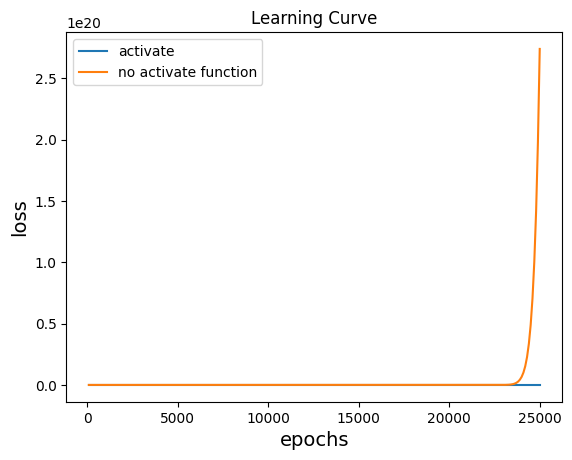

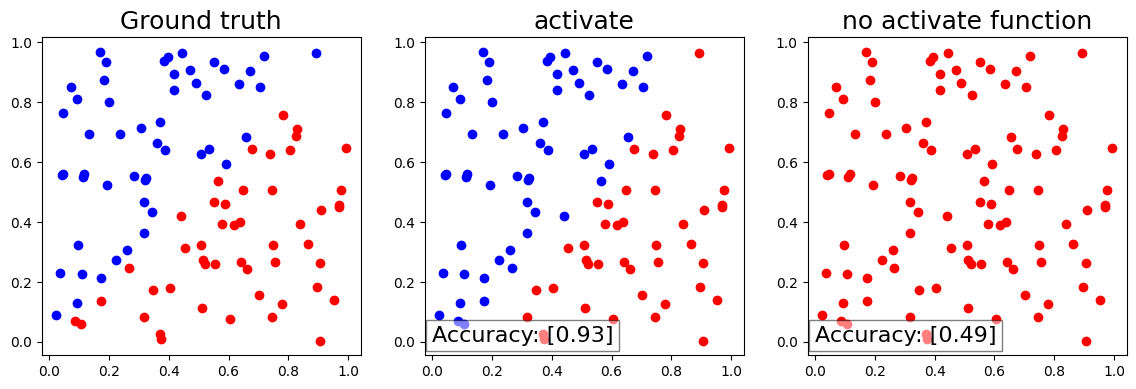

In [87]:
x,y =generate_linear()
epochs = 25000
model1 =Model(learning_rate= 1e-4)
model2 = Model(activate="None",learning_rate= 1e-4 )
# training
compare(x,y,model1,model2,"activate","no activate function",epochs)

### XOR Data

--------- activate Training -----------
epoch: 1000 loss: 0.011930278133341278
epoch: 2000 loss: 0.002352370084266966
epoch: 3000 loss: 0.0011637467848599143
epoch: 4000 loss: 0.0007517918445539154
epoch: 5000 loss: 0.000548872718136262
epoch: 6000 loss: 0.00042961391635486153
epoch: 7000 loss: 0.0003516567059298035
epoch: 8000 loss: 0.0002969425184783142
epoch: 9000 loss: 0.0002565378254522269
epoch: 10000 loss: 0.00022553922734524096
-------------activate Testing ------------
[[0.00679726]
 [0.99395164]
 [0.00861797]
 [0.99368286]
 [0.01173706]
 [0.99314198]
 [0.01566402]
 [0.9918725 ]
 [0.01874501]
 [0.96688752]
 [0.01956731]
 [0.01833631]
 [0.96672088]
 [0.01614249]
 [0.99469638]
 [0.01384906]
 [0.99596849]
 [0.01184112]
 [0.99626512]
 [0.01020624]
 [0.99638329]]
------------activate Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.00679726]
Iter:2 |      Ground truth : [1] |   prediction : [0.99395164]
Iter:3 |      Ground truth : [0] |   prediction : 

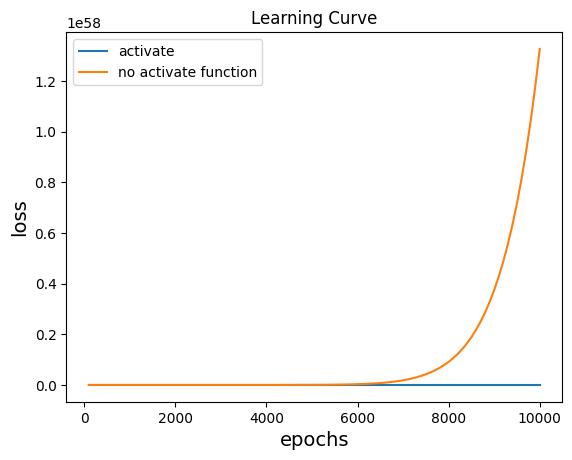

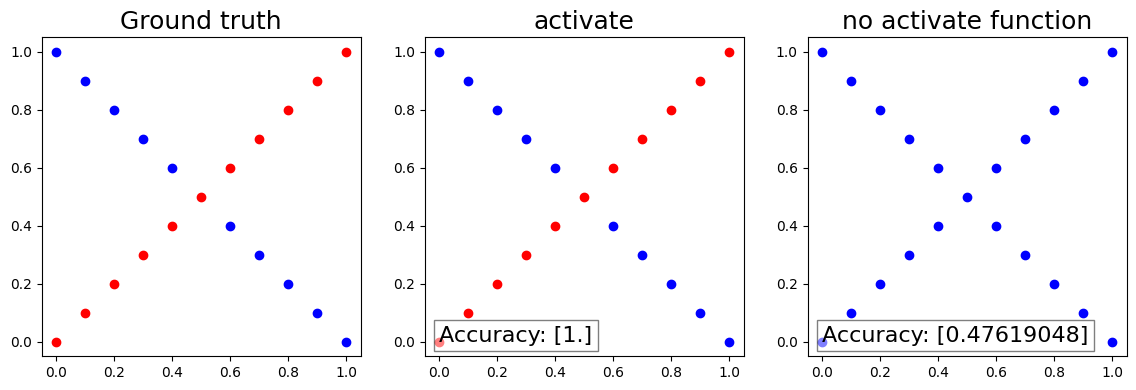

In [88]:
x_xor,y_xor =generate_XOR_easy()

epochs = 10000

model1 =Model( learning_rate= 1e-1)
model2 = Model(activate="None",learning_rate= 1e-1)
# training
compare(x_xor,y_xor,model1,model2,"activate","no activate function",epochs)

## Different hidden unit (5 vs 10)

### Linear Data

--------- 5 hidden unit Training -----------
epoch: 1000 loss: 0.2741248410446327
epoch: 2000 loss: 0.2371741159718524
epoch: 3000 loss: 0.23419205470218984
epoch: 4000 loss: 0.2322926288200573
epoch: 5000 loss: 0.23023281317553862
epoch: 6000 loss: 0.22795056730844065
epoch: 7000 loss: 0.22542126666479706
epoch: 8000 loss: 0.22262147487515485
epoch: 9000 loss: 0.21952860375123362
epoch: 10000 loss: 0.21612199430952078
-------------5 hidden unit Testing ------------
[[0.54055444]
 [0.43925472]
 [0.55867409]
 [0.46937736]
 [0.45751746]
 [0.44884827]
 [0.52727398]
 [0.53953353]
 [0.52058138]
 [0.48378351]
 [0.49120363]
 [0.4320918 ]
 [0.49404709]
 [0.47088328]
 [0.45162178]
 [0.55307442]
 [0.45632057]
 [0.49089541]
 [0.48823251]
 [0.42118934]
 [0.42280569]
 [0.41809957]
 [0.41885284]
 [0.54200999]
 [0.54154898]
 [0.48473625]
 [0.43848583]
 [0.55898252]
 [0.49207281]
 [0.51500333]
 [0.46940564]
 [0.47070617]
 [0.51375366]
 [0.46889817]
 [0.45330915]
 [0.46176782]
 [0.50178979]
 [0.4962335

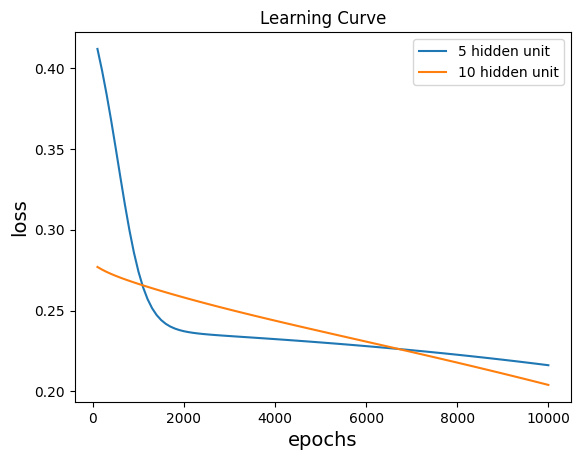

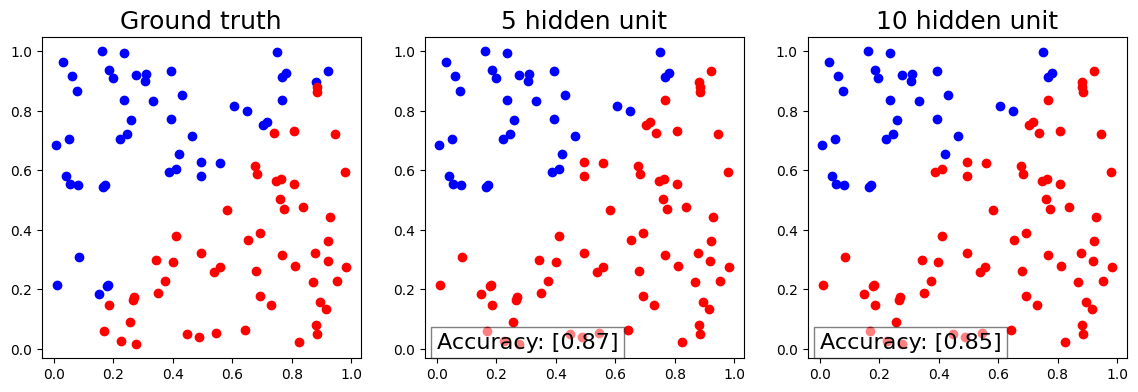

In [89]:
x,y =generate_linear()
epochs = 10000
model1 =Model(hidden1_size= 5,hidden2_size= 5,learning_rate= 1e-4)
model2 = Model(hidden1_size= 10,hidden2_size= 10,learning_rate= 1e-4 )
# training
compare(x,y,model1,model2,"5 hidden unit","10 hidden unit",epochs)

### XOR Data

--------- 5 hidden unit Training -----------
epoch: 1000 loss: 0.24863497665281548
epoch: 2000 loss: 0.24769389766033273
epoch: 3000 loss: 0.24651543485110824
epoch: 4000 loss: 0.2447043829337281
epoch: 5000 loss: 0.24182116278357177
epoch: 6000 loss: 0.23756611347715748
epoch: 7000 loss: 0.23219510343779243
epoch: 8000 loss: 0.22657415033914263
epoch: 9000 loss: 0.22146665207531036
epoch: 10000 loss: 0.21707075305111745
-------------5 hidden unit Testing ------------
[[0.10341085]
 [0.56197396]
 [0.15147288]
 [0.55786155]
 [0.25356082]
 [0.55367004]
 [0.39100331]
 [0.54953033]
 [0.49118776]
 [0.54556376]
 [0.54187073]
 [0.56567349]
 [0.53852332]
 [0.57746311]
 [0.53556306]
 [0.5838477 ]
 [0.53300338]
 [0.58766908]
 [0.5308348 ]
 [0.5902022 ]
 [0.52903147]]
------------5 hidden unit Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.10341085]
Iter:2 |      Ground truth : [1] |   prediction : [0.56197396]
Iter:3 |      Ground truth : [0] |   prediction : [0.15

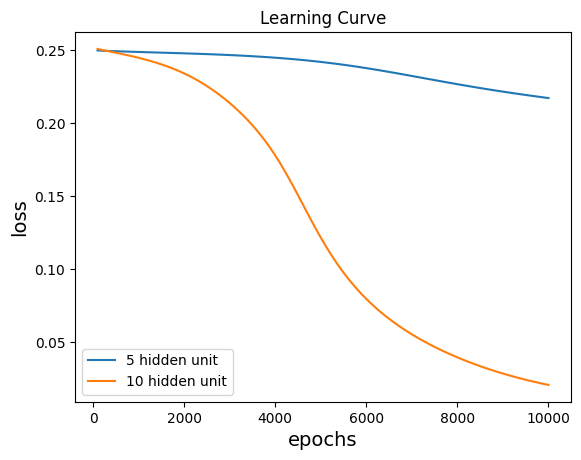

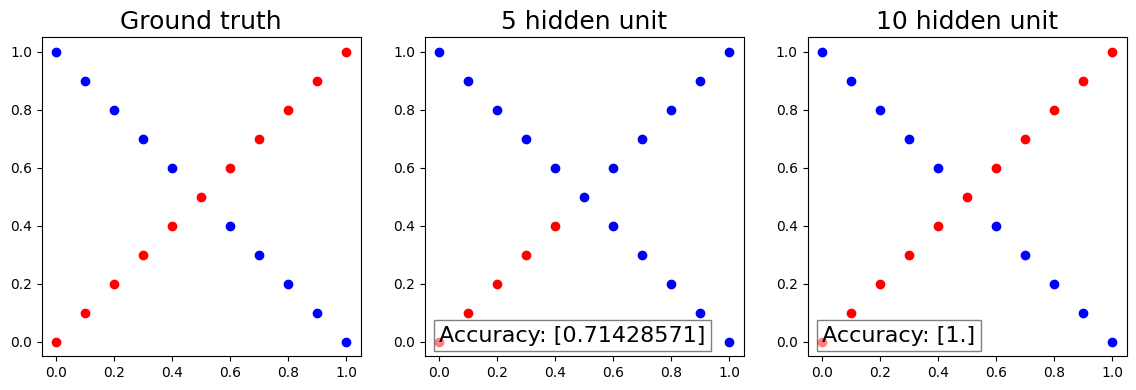

In [90]:
x_xor,y_xor =generate_XOR_easy()

epochs = 10000

model1 =Model( hidden1_size= 5,hidden2_size=5,learning_rate= 1e-2)
model2 = Model(hidden1_size= 10,hidden2_size=10,learning_rate= 1e-2)
# training
compare(x_xor,y_xor,model1,model2,"5 hidden unit","10 hidden unit",epochs)

# Extra

## Different activation function

### Linear Data

--------- Training -----------
epoch: 10000 loss: 0.009745336930803414
epoch: 20000 loss: 0.0082150584467598
epoch: 30000 loss: 0.007606973695575701
epoch: 40000 loss: 0.007009904198359467
epoch: 50000 loss: 0.0065555379343200555
------------- Testing ------------
[[ 9.99826562e-01]
 [ 1.44969873e-02]
 [-2.17592302e-02]
 [-1.31143560e-02]
 [ 9.99873063e-01]
 [-2.67276199e-02]
 [-4.23112536e-02]
 [ 9.93409697e-01]
 [ 9.33759230e-01]
 [ 9.99865414e-01]
 [-5.44195596e-03]
 [ 6.28104732e-01]
 [ 9.88141821e-01]
 [-2.23026667e-02]
 [ 9.99225752e-01]
 [ 4.97207629e-02]
 [ 9.99799366e-01]
 [-4.14754372e-04]
 [ 9.99902031e-01]
 [ 2.32194813e-02]
 [ 9.99825132e-01]
 [ 1.56233508e-02]
 [-2.01092899e-03]
 [-1.03561876e-02]
 [ 9.97403992e-01]
 [ 1.13024901e-01]
 [ 9.99898448e-01]
 [ 9.23398797e-04]
 [ 9.99846783e-01]
 [-8.80534830e-03]
 [ 5.51385719e-03]
 [ 9.50671023e-01]
 [ 9.99856196e-01]
 [-4.50081049e-02]
 [ 1.64603903e-02]
 [ 9.99906628e-01]
 [-7.57039092e-04]
 [ 9.99927850e-01]
 [-5.02816323

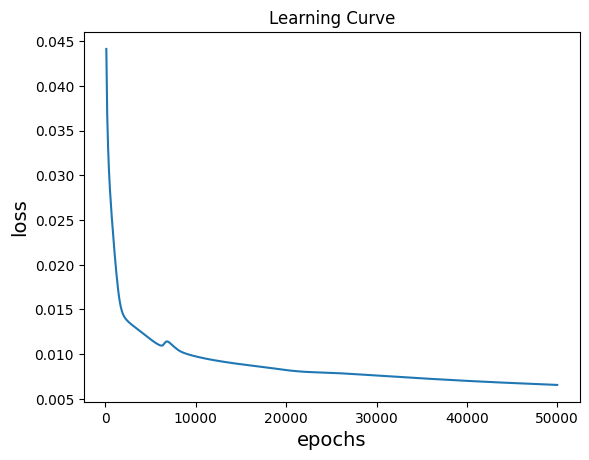

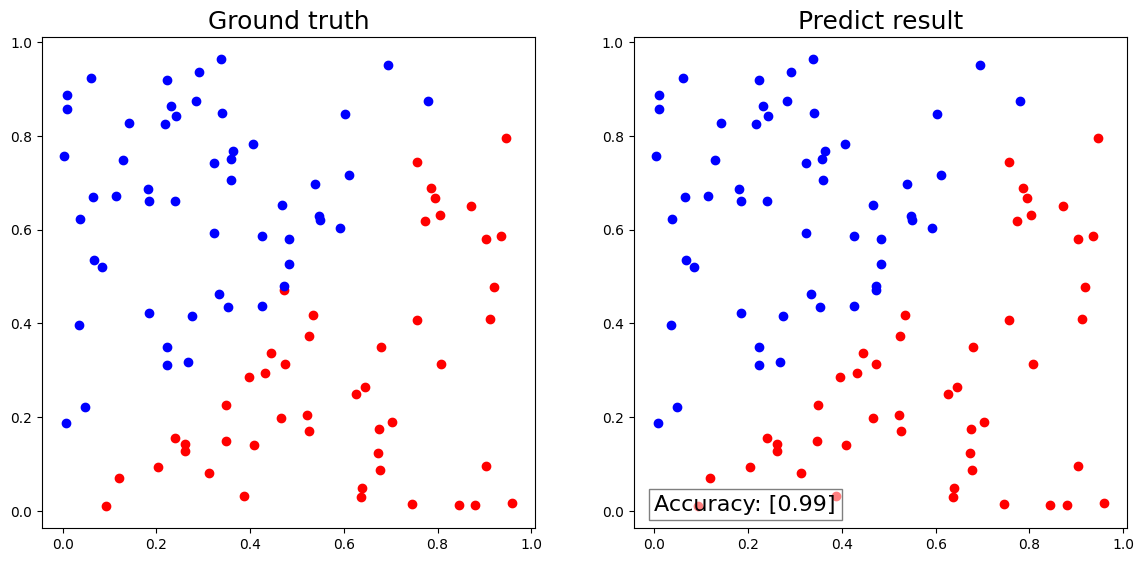

In [91]:
x,y =generate_linear()
epochs = 50000
model = Model(activate="tanh",learning_rate=1e-3)
# training
show(x,y,model,epochs)

### XOR Data

--------- Training -----------
epoch: 10000 loss: 0.0012399648921711025
epoch: 20000 loss: 0.0004917511999226965
epoch: 30000 loss: 0.0003047839025062872
epoch: 40000 loss: 0.0002220207443170997
epoch: 50000 loss: 0.00017539533868868502
------------- Testing ------------
[[-0.00205385]
 [ 0.99935795]
 [ 0.00886846]
 [ 0.99922782]
 [-0.00927167]
 [ 0.99884066]
 [-0.00686717]
 [ 0.99718803]
 [ 0.0067829 ]
 [ 0.96031941]
 [ 0.01237122]
 [ 0.00638814]
 [ 0.96575943]
 [-0.00419068]
 [ 0.99560403]
 [-0.01076027]
 [ 0.99483424]
 [-0.00700449]
 [ 0.99291137]
 [ 0.01069353]
 [ 0.99121771]]
------------Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [-0.00205385]
Iter:2 |      Ground truth : [1] |   prediction : [0.99935795]
Iter:3 |      Ground truth : [0] |   prediction : [0.00886846]
Iter:4 |      Ground truth : [1] |   prediction : [0.99922782]
Iter:5 |      Ground truth : [0] |   prediction : [-0.00927167]
Iter:6 |      Ground truth : [1] |   prediction : [0.99884

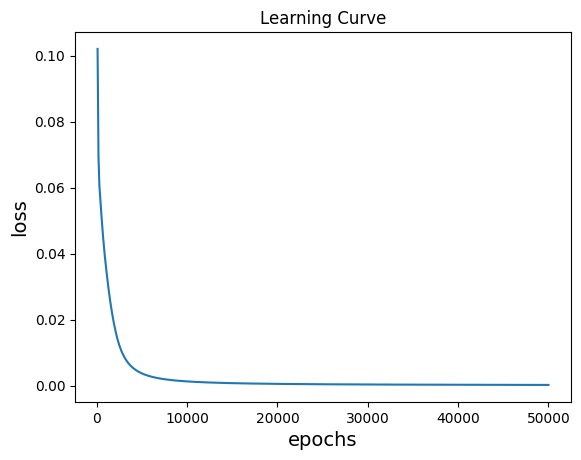

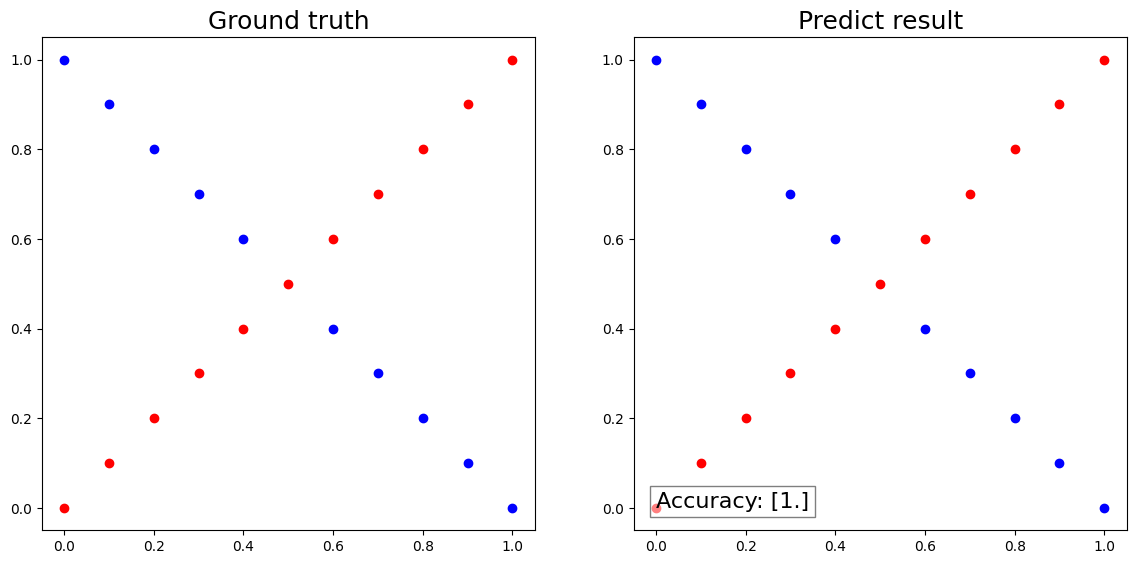

In [92]:
x_xor,y_xor =generate_XOR_easy()
epochs = 50000
model = Model(activate="tanh" ,learning_rate=1e-3)
# training
show(x_xor,y_xor,model,epochs)

## Different Optimizer

### Linear Data

--------- Training -----------
epoch: 10000 loss: 6.345301808764709e-05
epoch: 20000 loss: 2.5044358358640505e-05
epoch: 30000 loss: 1.4812734782457603e-05
epoch: 40000 loss: 1.028198675161349e-05
epoch: 50000 loss: 7.776510148565542e-06
------------- Testing ------------
[[9.99999993e-01]
 [9.99999993e-01]
 [6.35247737e-08]
 [9.99989756e-01]
 [3.96529826e-03]
 [9.99999992e-01]
 [9.99997484e-01]
 [9.99999992e-01]
 [9.99999992e-01]
 [6.44677878e-07]
 [9.99999991e-01]
 [6.57163447e-08]
 [2.87773837e-07]
 [7.27660013e-08]
 [9.99868684e-01]
 [4.23269395e-06]
 [9.98462642e-01]
 [9.99999990e-01]
 [1.35062165e-07]
 [8.68548905e-08]
 [9.42120427e-08]
 [9.99999990e-01]
 [1.90947510e-07]
 [9.99999992e-01]
 [9.99999994e-01]
 [9.99999992e-01]
 [7.82874876e-08]
 [9.10279855e-08]
 [9.17887082e-08]
 [6.06888011e-08]
 [9.33597990e-04]
 [9.99999994e-01]
 [9.99999989e-01]
 [5.17498090e-08]
 [1.91042404e-07]
 [5.35884478e-08]
 [5.34780846e-08]
 [9.99999994e-01]
 [1.66228439e-02]
 [9.99999994e-01]
 [5.836

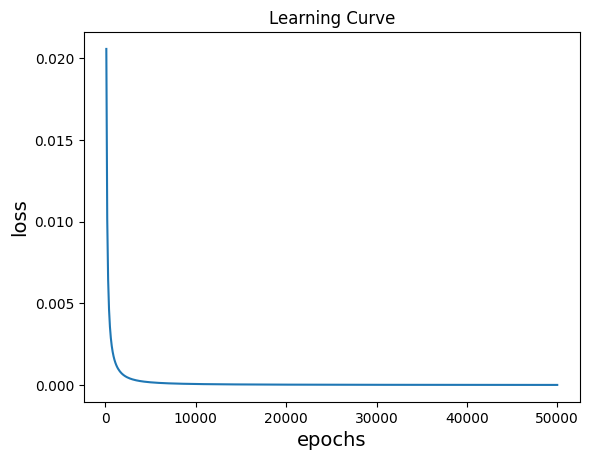

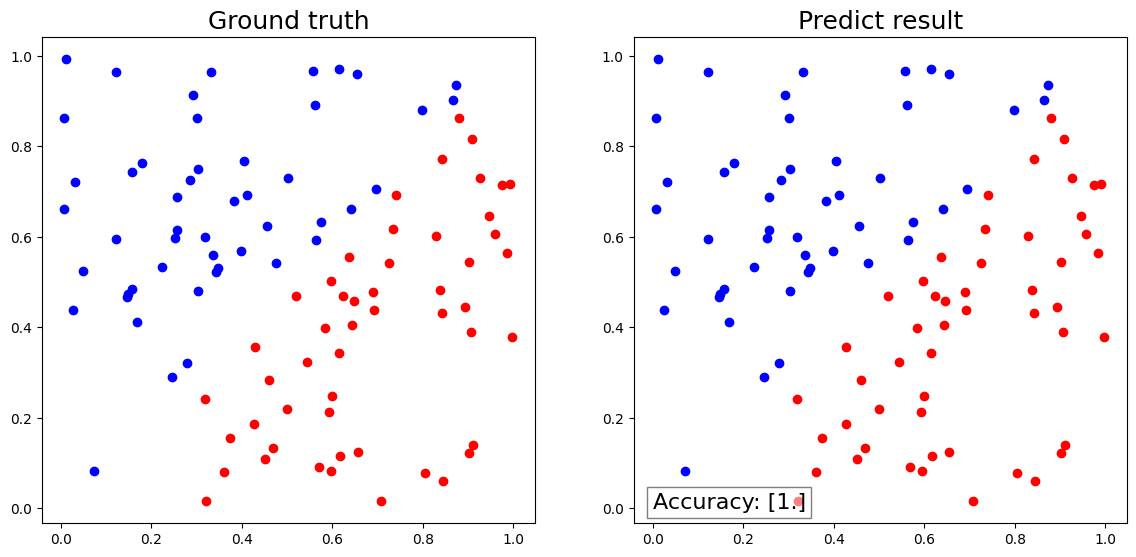

In [93]:
x,y =generate_linear()
epochs = 50000
model =Model(optimizer="Momentum",learning_rate=1e-2)
show(x,y,model,epochs)

### XOR Data

--------- Training -----------
epoch: 10000 loss: 0.00024664636528330024
epoch: 20000 loss: 0.00010721365456153848
epoch: 30000 loss: 6.788500043156436e-05
epoch: 40000 loss: 4.950393431567082e-05
epoch: 50000 loss: 3.889116343100721e-05
------------- Testing ------------
[[0.00121369]
 [0.99652897]
 [0.00270771]
 [0.99642268]
 [0.00516455]
 [0.9962656 ]
 [0.00749402]
 [0.99595452]
 [0.00852098]
 [0.98746601]
 [0.00825802]
 [0.0073607 ]
 [0.98642048]
 [0.00634316]
 [0.99757299]
 [0.00542862]
 [0.99785983]
 [0.00467009]
 [0.99758607]
 [0.00405595]
 [0.99697471]]
------------Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.00121369]
Iter:2 |      Ground truth : [1] |   prediction : [0.99652897]
Iter:3 |      Ground truth : [0] |   prediction : [0.00270771]
Iter:4 |      Ground truth : [1] |   prediction : [0.99642268]
Iter:5 |      Ground truth : [0] |   prediction : [0.00516455]
Iter:6 |      Ground truth : [1] |   prediction : [0.9962656]
Iter:7 |      Grou

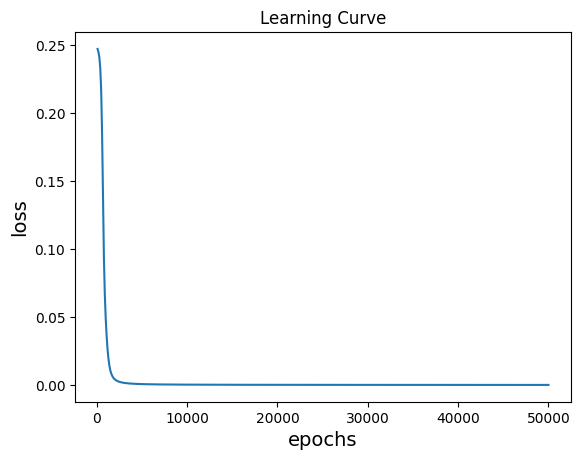

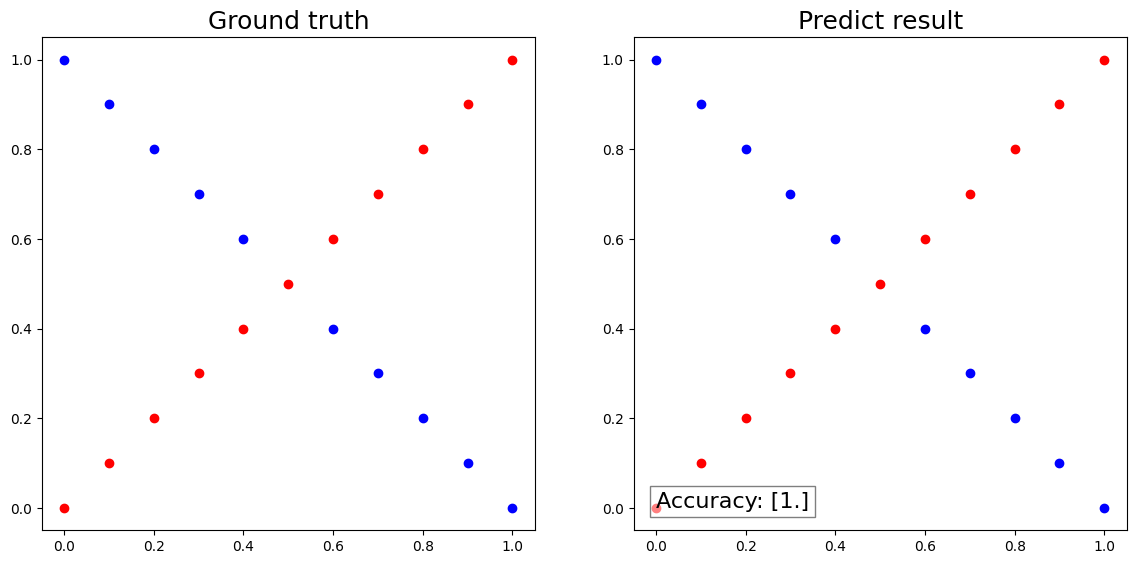

In [94]:
x_xor,y_xor =generate_XOR_easy()
epochs = 50000
model= Model(optimizer="Momentum" ,learning_rate=1e-2)
show(x_xor,y_xor,model,epochs)